In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/IDRA/Day15_Executive_Hotel_Booking_EDA_Dataset.csv")
df.head()

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

In [4]:
df.describe()

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Booking_Changes,Agent_ID,Company_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Estimated_Revenue
count,25180.000000,25180.000000,25180.000000,25180.000000,25059.000000,25180.000000,25180.000000,25180.000000,25180.000000,25180.000000,24876.000000,4451.000000,25180.000000,25180.000000,25098.000000,25180.000000,25180.000000,25016.000000,25180.000000,25180.000000
mean,182.200556,1.240429,2.451072,2.198967,0.372122,0.043050,0.172597,0.038642,1.117037,0.601191,89.698866,1059.135700,1.561438,3.693090,140.628124,0.228753,1.097458,3.854402,0.721763,535.495478
std,105.604452,1.063802,2.031003,0.662379,0.657811,0.225057,0.377906,0.251403,2.829046,0.894293,51.731839,34.270543,4.459498,2.085623,47.808034,0.530060,1.047671,0.405110,0.448140,389.700003
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1001.000000,0.000000,1.000000,30.800000,0.000000,0.000000,0.300000,0.000000,31.820000
25%,91.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1029.000000,0.000000,2.000000,105.620000,0.000000,0.000000,3.590000,0.000000,230.540000
50%,182.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89.000000,1059.000000,0.000000,4.000000,134.425000,0.000000,1.000000,3.860000,1.000000,448.735000
75%,273.000000,2.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,135.000000,1088.000000,1.000000,5.000000,169.097500,0.000000,2.000000,4.130000,1.000000,737.577500
max,920.000000,3.000000,13.000000,7.000000,6.000000,2.000000,1.000000,3.000000,12.000000,4.000000,179.000000,1119.000000,180.000000,45.000000,710.500000,3.000000,5.000000,5.900000,1.000000,3256.020000


##Dropping unnecessary rows and columns

In [5]:
df.nunique()

,0
Booking_ID,25000
Hotel_Type,5
Hotel_Location,11
Booking_Date,731
Arrival_Date,1073
Lead_Time_Days,368
Weekend_Nights,4
Weekday_Nights,14
Adults,5
Children,5


In [6]:
# missing values
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing

,0
Company_ID,82.323272
Country,1.850675
Agent_ID,1.207307
Meal_Type,0.972994
Satisfaction_Score,0.651311
Children,0.480540
Hotel_Location,0.420969
ADR,0.325655
Booking_ID,0.000000
Hotel_Type,0.000000


In [7]:
df.duplicated().sum()

np.int64(180)

In [8]:
df = df.drop_duplicates()
df.shape

(25000, 35)

In [9]:
df = df.drop(columns=['Agent_ID', 'Company_ID'])
df.shape

(25000, 33)

##Filling missing values

In [10]:
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df['Meal_Type'] = df['Meal_Type'].fillna(df['Meal_Type'].mode()[0])
df['Hotel_Location'] = df['Hotel_Location'].fillna(df['Hotel_Location'].mode()[0])

In [11]:
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())
df['Children'] = df['Children'].fillna(0)
df['ADR'] = df['ADR'].fillna(df['ADR'].median())

In [12]:
df.isnull().sum().sum()

np.int64(0)

##Correcting incorrect datatypes

In [13]:
dates = ['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']
for date in dates:
  df[date] = pd.to_datetime(df[date])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 25179
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Booking_ID                   25000 non-null  object        
 1   Hotel_Type                   25000 non-null  object        
 2   Hotel_Location               25000 non-null  object        
 3   Booking_Date                 25000 non-null  datetime64[ns]
 4   Arrival_Date                 25000 non-null  datetime64[ns]
 5   Lead_Time_Days               25000 non-null  int64         
 6   Weekend_Nights               25000 non-null  int64         
 7   Weekday_Nights               25000 non-null  int64         
 8   Adults                       25000 non-null  int64         
 9   Children                     25000 non-null  float64       
 10  Babies                       25000 non-null  int64         
 11  Country                      25000 non-null  o

##Correcting inconsistent values

In [14]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print("\n", col)
    print(df[col].unique())


 Booking_ID
['HTL024548' 'HTL019878' 'HTL017377' ... 'HTL005715' 'HTL020611'
 'HTL011248']

 Hotel_Type
['City Hotel' 'Resort Hotel' 'CITY HOTEL' 'city hotel' 'City hotel']

 Hotel_Location
['London' 'Lisbon' 'Dubai' 'Maldives' 'Amsterdam' 'Algarve' 'Barcelona'
 'Goa' 'Bali' 'Phuket' 'Unknown']

 Country
['ARE' 'JPN' 'POL' 'CAN' 'PRT' 'DNK' 'BRA' 'AUS' 'GBR' 'ESP' 'FRA' 'IND'
 'USA' 'NOR' 'NLD' 'DEU' 'IRL' 'SWE' 'CHE' 'ITA' 'BEL' 'CHN' 'SAU'
 'Unknown']

 Market_Segment
['Direct' 'Groups' 'Online TA' 'Offline TA/TO' 'Online TA ' 'Corporate'
 'online ta' 'ONLINE TA']

 Distribution_Channel
['Direct' 'TA/TO' 'Corporate']

 Room_Type_Reserved
['H' 'D' 'C' 'G' 'A' 'E' 'B' 'F']

 Room_Type_Assigned
['H' 'D' 'C' 'E' 'G' 'B' 'A' 'F']

 Deposit_Type
['Non Refund' 'No Deposit' 'Refundable']

 Customer_Type
['Contract' 'Transient' 'Group' 'Transient-Party']

 Meal_Type
['HB' 'Undefined' 'FB' 'SC' 'BB' 'BB ' 'bb' ' B&B ' 'Unknown']

 Reservation_Status
['No-Show' 'Canceled' 'Check-Out']


In [15]:
redo_cat_col = ['Hotel_Type', 'Market_Segment', 'Meal_Type']
for col in redo_cat_col:
  df[col] = df[col].str.strip().str.title()

for col in cat_cols:
    print("\n", col)
    print(df[col].unique())


 Booking_ID
['HTL024548' 'HTL019878' 'HTL017377' ... 'HTL005715' 'HTL020611'
 'HTL011248']

 Hotel_Type
['City Hotel' 'Resort Hotel']

 Hotel_Location
['London' 'Lisbon' 'Dubai' 'Maldives' 'Amsterdam' 'Algarve' 'Barcelona'
 'Goa' 'Bali' 'Phuket' 'Unknown']

 Country
['ARE' 'JPN' 'POL' 'CAN' 'PRT' 'DNK' 'BRA' 'AUS' 'GBR' 'ESP' 'FRA' 'IND'
 'USA' 'NOR' 'NLD' 'DEU' 'IRL' 'SWE' 'CHE' 'ITA' 'BEL' 'CHN' 'SAU'
 'Unknown']

 Market_Segment
['Direct' 'Groups' 'Online Ta' 'Offline Ta/To' 'Corporate']

 Distribution_Channel
['Direct' 'TA/TO' 'Corporate']

 Room_Type_Reserved
['H' 'D' 'C' 'G' 'A' 'E' 'B' 'F']

 Room_Type_Assigned
['H' 'D' 'C' 'E' 'G' 'B' 'A' 'F']

 Deposit_Type
['Non Refund' 'No Deposit' 'Refundable']

 Customer_Type
['Contract' 'Transient' 'Group' 'Transient-Party']

 Meal_Type
['Hb' 'Undefined' 'Fb' 'Sc' 'Bb' 'B&B' 'Unknown']

 Reservation_Status
['No-Show' 'Canceled' 'Check-Out']


In [16]:
df['Market_Segment'] = df['Market_Segment'].replace({
    'Online Ta': 'Online TA',
    'Offline Ta/To': 'Offline TA/TO'
})

df['Meal_Type'] = df['Meal_Type'].replace({
    'Hb': 'HB',
    'Fb': 'FB',
    'Sc': 'SC',
    'Bb': 'BB',
    'B&B': 'BB'
})

for col in cat_cols:
    print("\n", col)
    print(df[col].unique())


 Booking_ID
['HTL024548' 'HTL019878' 'HTL017377' ... 'HTL005715' 'HTL020611'
 'HTL011248']

 Hotel_Type
['City Hotel' 'Resort Hotel']

 Hotel_Location
['London' 'Lisbon' 'Dubai' 'Maldives' 'Amsterdam' 'Algarve' 'Barcelona'
 'Goa' 'Bali' 'Phuket' 'Unknown']

 Country
['ARE' 'JPN' 'POL' 'CAN' 'PRT' 'DNK' 'BRA' 'AUS' 'GBR' 'ESP' 'FRA' 'IND'
 'USA' 'NOR' 'NLD' 'DEU' 'IRL' 'SWE' 'CHE' 'ITA' 'BEL' 'CHN' 'SAU'
 'Unknown']

 Market_Segment
['Direct' 'Groups' 'Online TA' 'Offline TA/TO' 'Corporate']

 Distribution_Channel
['Direct' 'TA/TO' 'Corporate']

 Room_Type_Reserved
['H' 'D' 'C' 'G' 'A' 'E' 'B' 'F']

 Room_Type_Assigned
['H' 'D' 'C' 'E' 'G' 'B' 'A' 'F']

 Deposit_Type
['Non Refund' 'No Deposit' 'Refundable']

 Customer_Type
['Contract' 'Transient' 'Group' 'Transient-Party']

 Meal_Type
['HB' 'Undefined' 'FB' 'SC' 'BB' 'Unknown']

 Reservation_Status
['No-Show' 'Canceled' 'Check-Out']


##Checking for outliers

In [17]:
df.describe()

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Booking_Changes,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,0.601160,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,4.000000,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,0.894359,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257


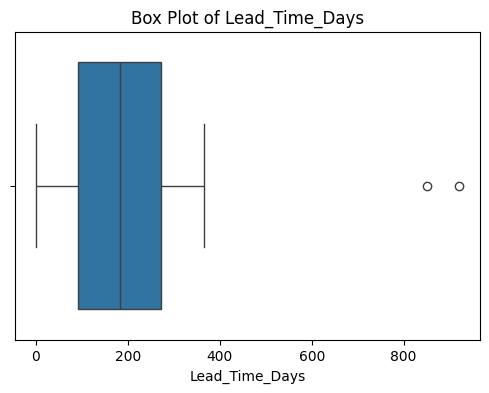

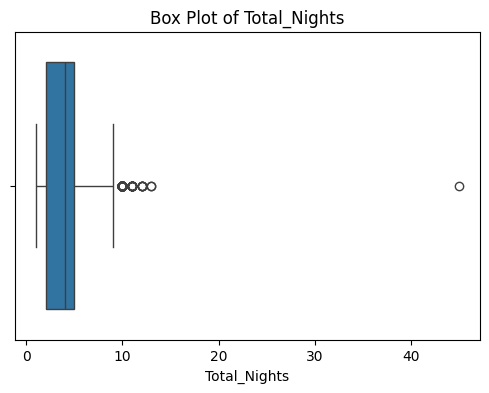

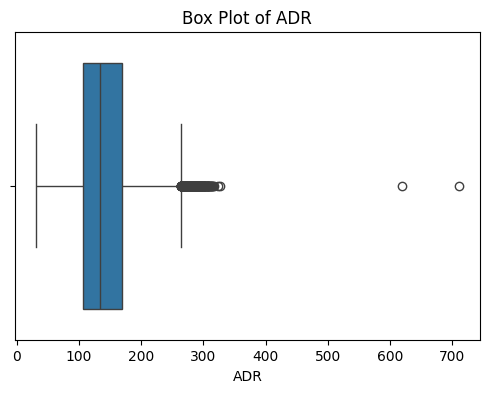

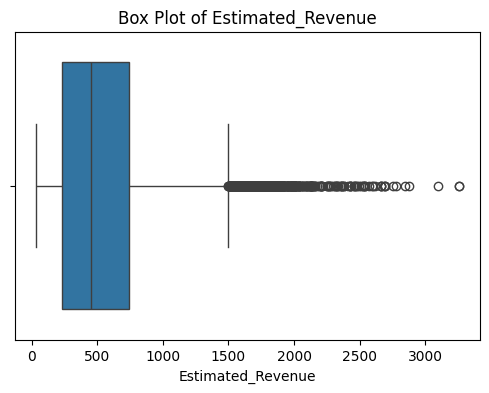

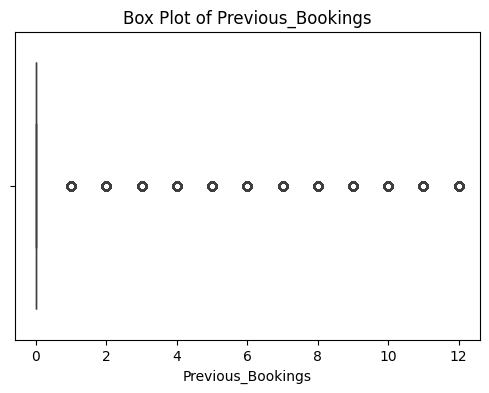

In [18]:
cols = ['Lead_Time_Days', 'Total_Nights', 'ADR', 'Estimated_Revenue', 'Previous_Bookings']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

Observations from the box plots:
- Lead_Time_Day: A small no. of bookings were made far in adavance; possibility in hotel bookings
- Total_Nights: Usually, customers have relatively short stays, but there are few bookings with unusually long stays, also possible
- ADR: Some bookings have expectionally high daily room rates. must be investigated
- Estimated_Revenue: Most bookings generate moderate revenue, while some generate relatively higher revenue
- Previous_Bookings: Most guests have not made any previous bookings, that is why the box appears to be a line.

These observations may represent genuine business cases rather than data entry errors, so they are retained for the analysis

##Descriptive statistics

In [19]:
df.describe(include='object')

,Booking_ID,Hotel_Type,Hotel_Location,Country,Market_Segment,Distribution_Channel,Room_Type_Reserved,Room_Type_Assigned,Deposit_Type,Customer_Type,Meal_Type,Reservation_Status
count,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000
unique,25000,2,11,24,5,3,8,8,3,4,6,3
top,HTL011248,City Hotel,Dubai,BRA,Online TA,TA/TO,D,C,Non Refund,Contract,BB,Canceled
freq,1,15611,3253,1614,10852,16887,3207,3199,12401,6403,5341,16606


- City Hotel is the most freguently booked hotel type
- Dubai is the place with the most number of bookings
- Customers from the country BRA have booked the most
- Most customers book through online travel agency(s) and distribution channel mostly used is TA/TO
- Non refund deposit type is most frequent among customers
- Bed & Breakfast is frequently selected meal option
- Cancellation is frequent with 16606 bookings being cancelled, this behaviour must be investigated

In [20]:
df.describe(include='number')

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Booking_Changes,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Estimated_Revenue
count,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000
mean,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,1.11852,0.601160,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,535.367978
std,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,2.83032,0.894359,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,389.640257
min,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,31.820000
25%,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,230.620000
50%,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,448.735000
75%,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,0.00000,1.000000,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,737.570000
max,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,12.00000,4.000000,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,3256.020000


- Most customers do not have previous booking
- most bookings have no waiting-list days
- some bookings generate considerably higher revenue

In [21]:
df.describe(include='datetime')

,Booking_Date,Arrival_Date,Reservation_Status_Date
count,25000,25000,25000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,2025-07-04 02:15:31.967999744
min,2024-01-01 00:00:00,2024-01-02 00:00:00,2024-01-02 00:00:00
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,2025-01-01 00:00:00
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,2025-07-04 00:00:00
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,2026-01-05 00:00:00
max,2025-12-31 00:00:00,2026-12-29 00:00:00,2026-12-30 00:00:00


##Univariate analysis

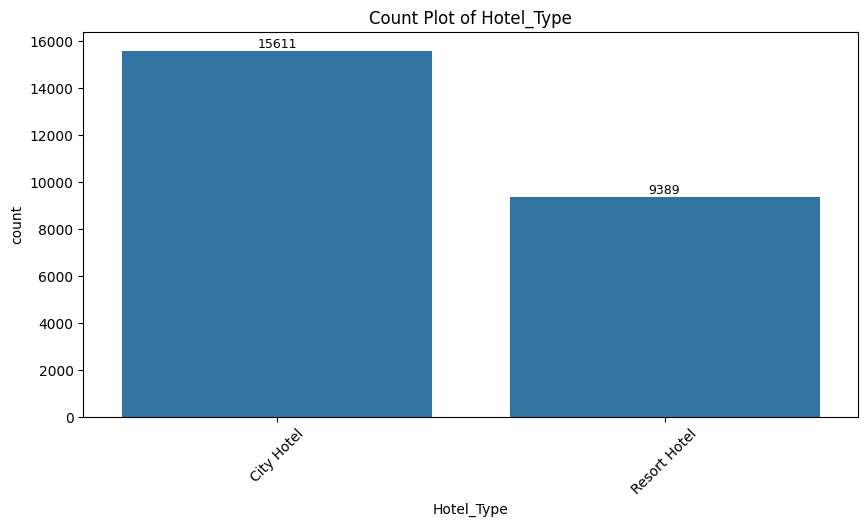

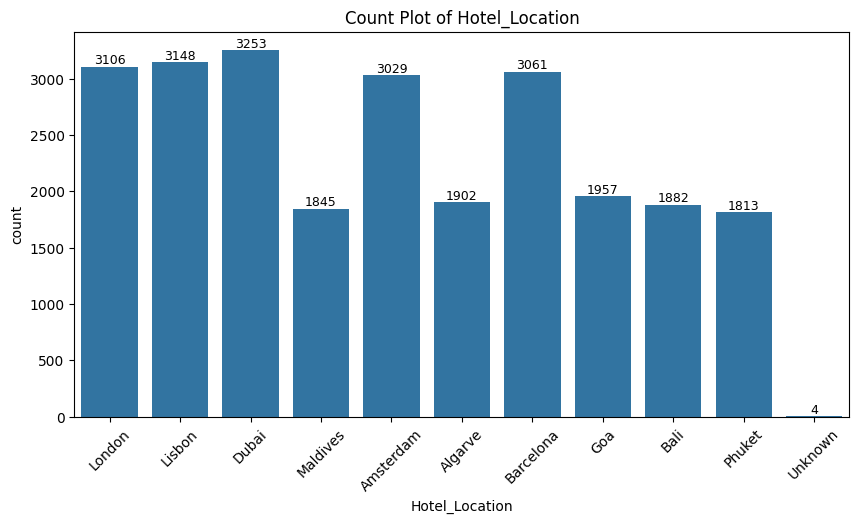

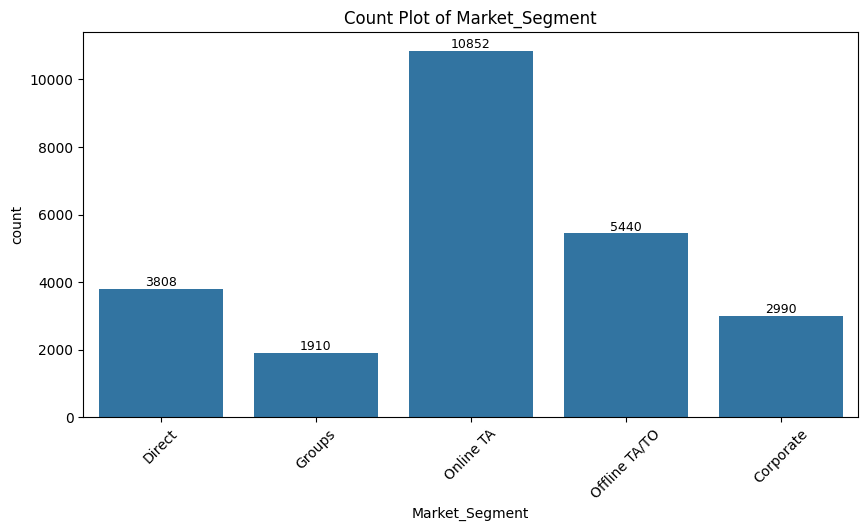

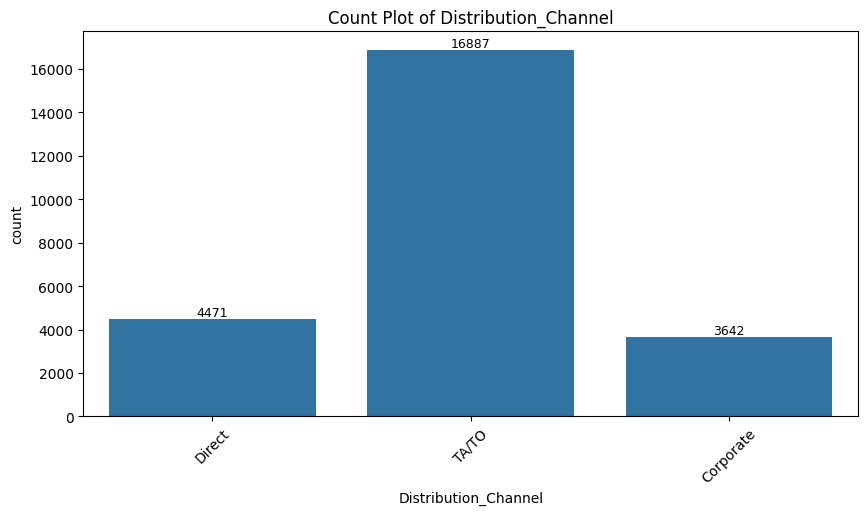

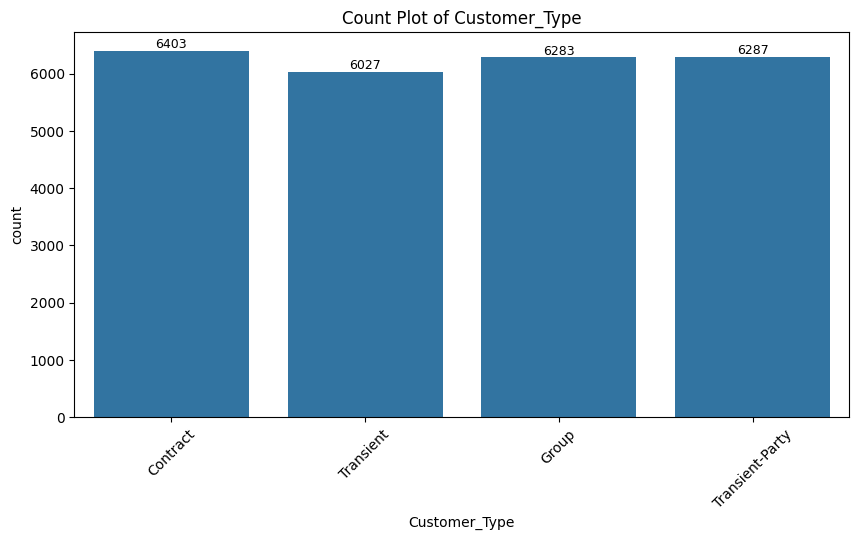

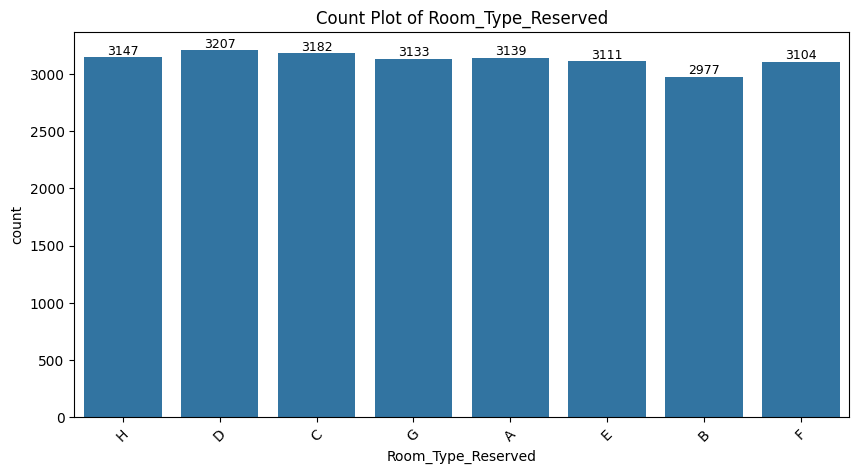

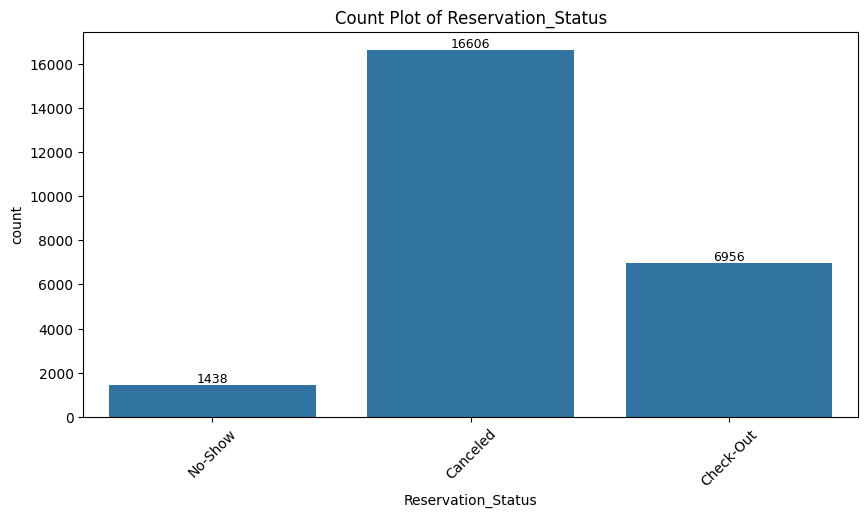

In [22]:
cat_cols = ['Hotel_Type', 'Hotel_Location', 'Market_Segment', 'Distribution_Channel', 'Customer_Type', 'Room_Type_Reserved', 'Reservation_Status']
for i in cat_cols:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x=df[i])
    plt.title(f'Count Plot of {i}')
    plt.xticks(rotation=45)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9, color='black')

    plt.show()

- City hotels dominate the dataset
- The Dubai hotel has the highest no. of bookings, and Phuket has the lowest.
- Online TA is the dominant market segment
- TA/TO has the majority of the bookings done
- The four types of customers have similar booking counts, but the Contract customer count is the highest
- Bookings across the different room types are fairly distributed, with the D type being the highest
- Cancelled bookings are the largest group, indicating it should be further investigated

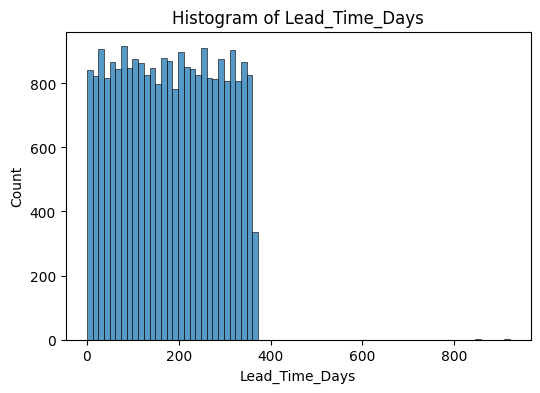

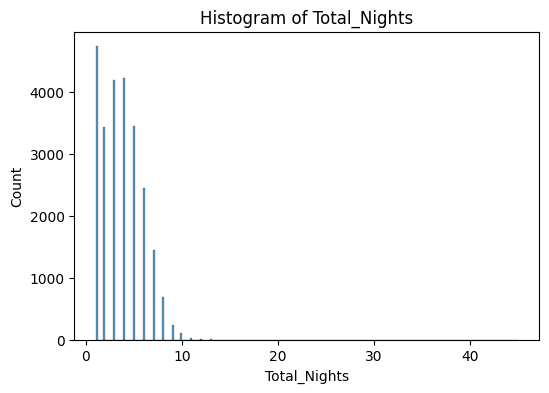

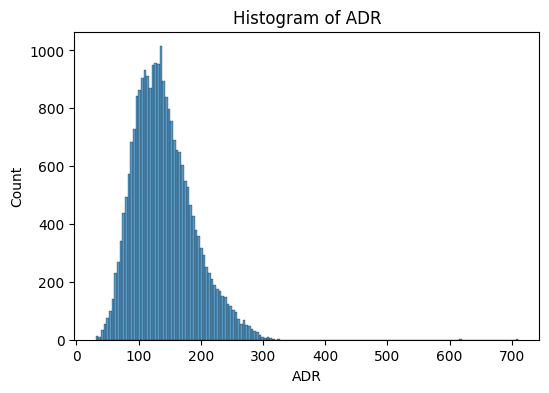

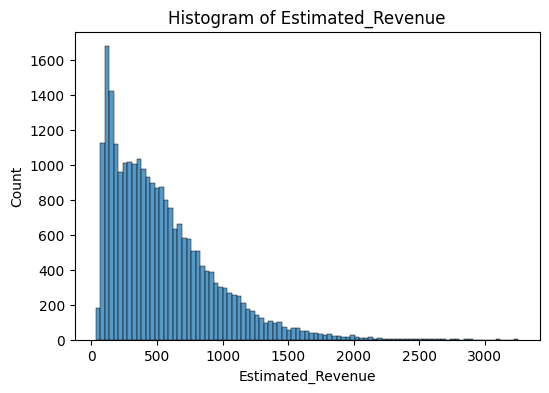

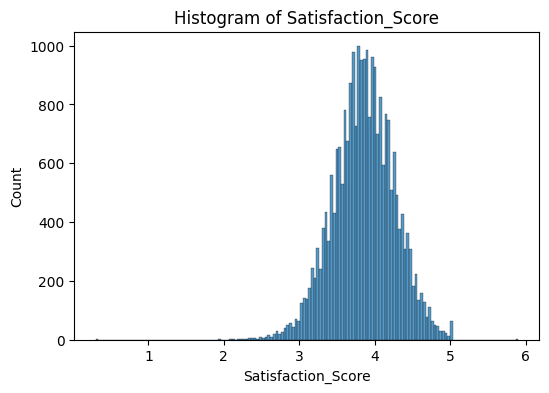

In [23]:
num_cols = ['Lead_Time_Days', 'Total_Nights', 'ADR', 'Estimated_Revenue', 'Satisfaction_Score']
for i in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(x=df[i])
    plt.title(f'Histogram of {i}')
    plt.show()

- Lead times are spread from 0 to around 380 days, with a few extremely high values (outliers) extending upto 900 days
- Almost all customers spend 1 to 10 nights (short stays)
- ADR is mainly concentrated around 100-200
- Most bookings generate relatively lower revenue while smaller no. of bookings generate substantially higher revenue (there are outliers in the plot)
- The satisfaction scores are strongly concentrated around 3.5 to 4.5, so customer satisfaction is generally positive

##Bivariate Analysis

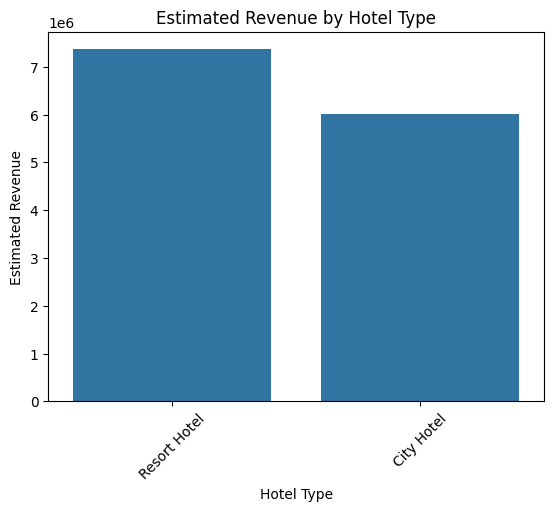

In [24]:
hotel_revenue = df.groupby('Hotel_Type')['Estimated_Revenue'].sum().sort_values(ascending=False)

sns.barplot(
    x=hotel_revenue.index,
    y=hotel_revenue.values
)

plt.title('Estimated Revenue by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Estimated Revenue')
plt.xticks(rotation=45)
plt.show()

Resort Hotels generate higher estimated revenue than City Hotels, supported by their considerably higher average daily rate (ADR).

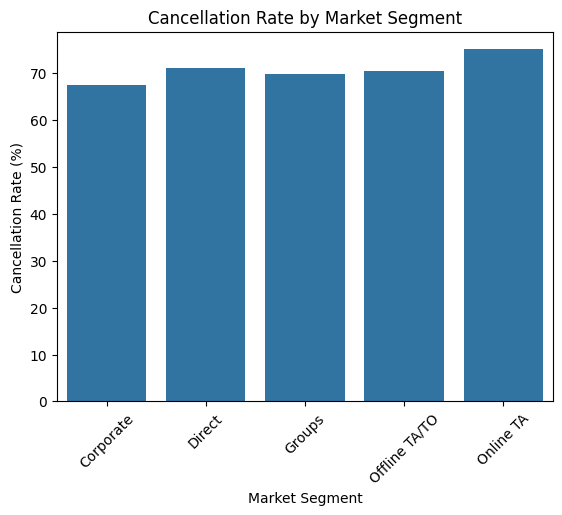

In [25]:
cancellation_rate = df.groupby('Market_Segment')['Is_Canceled'].mean() * 100
cancellation_rate.sort_values(ascending=False)

sns.barplot(
    x=cancellation_rate.index,
    y=cancellation_rate.values
)

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.show()

Online TA bookings have the highest cancellation rate, while Corporate bookings have the lowest, indicating that cancellation behavior varies across market segments.

##Group-wise Analysis

In [26]:
df.groupby('Hotel_Type').agg({
    'Estimated_Revenue': 'sum',
    'ADR': 'mean',
    'Is_Canceled': 'mean',
    'Satisfaction_Score': 'mean'
})

,Estimated_Revenue,ADR,Is_Canceled,Satisfaction_Score
Hotel_Type,,,,
City Hotel,6018324.50,120.759541,0.733009,3.851931
Resort Hotel,7365874.95,173.556962,0.703057,3.858518


Resort Hotels outperform City Hotels in revenue and ADR while maintaining a slightly lower cancellation rate. Customer satisfaction, however, is almost the same for both.

In [27]:
df.groupby('Market_Segment').agg({
    'Estimated_Revenue': 'sum',
    'ADR': 'mean',
    'Is_Canceled': 'mean'
})

,Estimated_Revenue,ADR,Is_Canceled
Market_Segment,,,
Corporate,1492611.61,134.156130,0.674916
Direct,2098049.99,143.249165,0.712185
Groups,917235.87,125.317050,0.697906
Offline TA/TO,2944293.73,142.393578,0.704228
Online TA,5932008.25,143.209292,0.751014


Online TA is the largest revenue-generating market segment but also has the highest cancellation rate, suggesting that its strong booking volume is accompanied by greater booking uncertainty.

In [28]:
df.groupby('Customer_Type').agg({
    'Estimated_Revenue': 'sum',
    'ADR': 'mean',
    'Is_Canceled': 'mean'
})

,Estimated_Revenue,ADR,Is_Canceled
Customer_Type,,,
Contract,3461023.69,140.720939,0.719506
Group,3355007.34,140.608356,0.727041
Transient,3251091.77,141.162575,0.723411
Transient-Party,3317076.65,139.882011,0.717194


Revenue and ADR are relatively similar across customer types, while cancellation rates also remain within a narrow range. Therefore, customer type does not appear to create a major difference in overall booking performance.

##Correlation Analysis

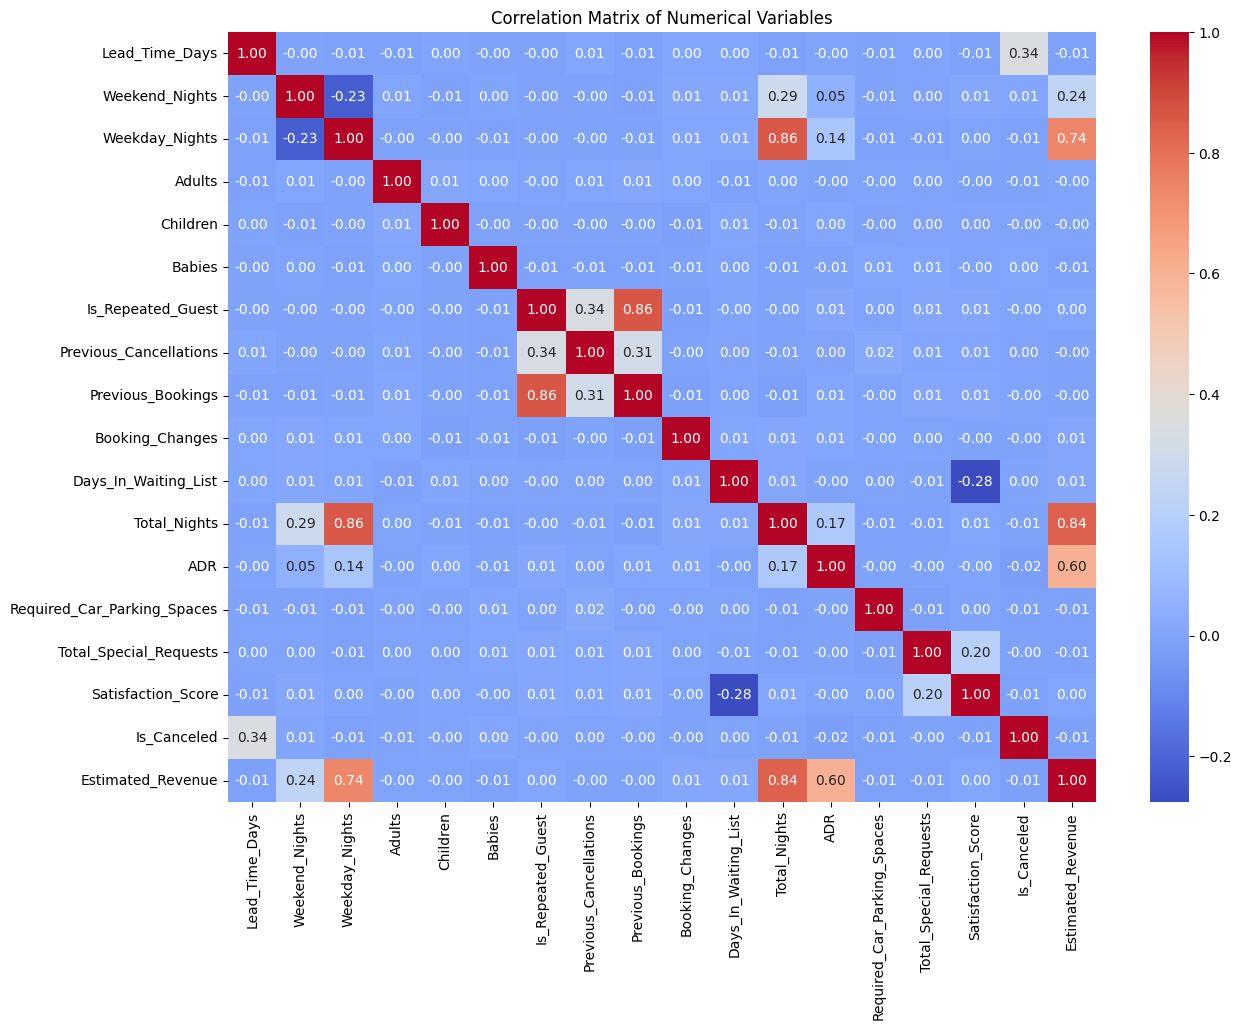

In [29]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

- the score between Total_Nights and Estimated_Revenue is 0.84 => the longer the stays are, the higher the generated revenue is
- ADR and Estimated_Revenue is also strongly correlated (0.60)
- Longer lead times have a moderately positive association with cancellation (0.34)
- Longer waiting time negatively affects the customer satisfaction score (-0.28)

#Summary

- After checking the dataset information and descriptive statistics, duplicate rows were removed, reducing the dataset from 25,180 to 25,000 records.
- Agent_ID and Company_ID were dropped as identifier columns that were not required for the analysis.
- Date columns were converted from object type to datetime format for proper date-based analysis.
- Missing values were handled using mode for categorical columns and median for numerical columns.
- Inconsistent categorical values were cleaned and standardized for consistency.
- Outliers in Lead_Time_Days, Total_Nights, ADR, Estimated_Revenue, and Previous_Bookings were investigated and retained, as they may represent genuine hotel booking scenarios.
- City Hotel has the highest number of bookings, while Dubai is the most frequently booked location.
- Online TA is the dominant market segment, while TA/TO is the most frequently used distribution channel.
- Cancellation is a major concern, with 16,606 bookings being cancelled; Online TA has the highest cancellation rate among the market segments.
- Resort Hotels generate higher estimated revenue and have a higher average ADR than City Hotels, while both hotel types have nearly similar satisfaction scores.
- Most customers have no previous bookings, suggesting that a large proportion of the bookings come from first-time customers.
- Most bookings have no waiting-list days, indicating that reservations are generally processed without prolonged waiting.
- Most stays are relatively short, with the majority of bookings having around 1–10 nights.
- Revenue is generally concentrated at lower to moderate levels, while a smaller number of bookings generate substantially higher revenue.
- Total_Nights has a strong positive relationship with Estimated_Revenue (0.84), indicating that longer stays generally contribute to higher revenue.
- ADR also has a positive relationship with Estimated_Revenue (0.60), suggesting that higher room rates contribute to increased revenue.
- Lead_Time_Days has a moderate positive relationship with cancellations (0.34), indicating that bookings made further in advance tend to have a higher likelihood of cancellation.
- Days_In_Waiting_List has a negative relationship with Satisfaction_Score (-0.28), suggesting that longer waiting periods may be associated with lower customer satisfaction.

Overall, the analysis indicates that revenue is mainly influenced by stay duration and room rates, while cancellations—particularly among Online TA bookings—are an important area for further investigation.